In [2]:
%pip uninstall -y faiss-cpu faiss-gpu faiss-gpu-cu11 faiss-gpu-cu12
%pip install -q --upgrade --upgrade-strategy only-if-needed \
  "transformers==4.49.0" \
  "sentence-transformers==3.4.1" \
  "tokenizers>=0.21,<0.22" \
  "sentencepiece>=0.2.0" \
  "safetensors>=0.4.5" \
  "faiss-gpu-cu12>=1.10.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 132.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 77.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 17.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 38.6 MB/s eta 0:00:00


In [3]:
# 1. Imports, CUDA validation, and reproducibility

import os
import gc
import csv
import json
import math
import time
import random
import zipfile
import urllib.request
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import faiss

import torch
import torch.nn.functional as F
from sentence_transformers import SentenceTransformer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

if not torch.cuda.is_available():
    raise RuntimeError(
        "CUDA GPU is required. In Colab: Runtime > Change runtime type > T4 GPU."
    )

DEVICE = torch.device("cuda")
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True

print("GPU:", torch.cuda.get_device_name(0))
print("CUDA:", torch.version.cuda)
print("Faiss:", faiss.__version__)
print("FAISS visible GPUs:", faiss.get_num_gpus())
if faiss.get_num_gpus() < 1:
    raise RuntimeError(
        "CUDA PyTorch is available, but this FAISS build has no GPU backend. "
        "Restart the Colab runtime after installing faiss-gpu-cu12, then re-run from Cell 1."
    )


GPU: Tesla T4
CUDA: 12.8
Faiss: 1.14.1
FAISS visible GPUs: 1


In [4]:
# 2. Experiment configuration

FIQA_URL = "https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/fiqa.zip"
DATA_DIR = Path("beir_data")
FIQA_DIR = DATA_DIR / "fiqa"

EMBEDDING_MODEL = "sentence-transformers/all-MiniLM-L6-v2"
DOC_EMBED_BATCH_SIZE = 256
QUERY_EMBED_BATCH_SIZE = 256

# Full FiQA corpus; keep all documents so no judged relevant document is dropped.
MAX_DOCS = None
MAX_QUERIES = None

RETRIEVAL_K_VALUES = [5, 10]
RANKING_K = max(RETRIEVAL_K_VALUES + [10])

# GPU K-means controls
KMEANS_TRAIN_POINTS = 24_000
KMEANS_BATCH_SIZE = 4096
KMEANS_MAX_ITER = 30
KMEANS_TOL = 1e-4

# First FiQA RAG sweep: use the strongest / most informative configurations from AG News.
# Add more settings after this benchmark is stable.
PQ_SETTINGS = [
    (24, 256),
    (48, 256),
    (64, 256),
    (96, 256),
]
OPQ_SETTINGS = [
    (24, 8),
    (48, 8),
    (64, 8),
    (96, 8),
]
OPQ_OUTER_ITERS = 6
OPQ_PQ_INNER_ITERS = 18

RESULT_DIR = Path("fiqa_rag_results")
RESULT_DIR.mkdir(exist_ok=True, parents=True)

print("Model:", EMBEDDING_MODEL)
print("PQ:", PQ_SETTINGS)
print("OPQ:", OPQ_SETTINGS)

Model: sentence-transformers/all-MiniLM-L6-v2
PQ: [(24, 256), (48, 256), (64, 256), (96, 256)]
OPQ: [(24, 8), (48, 8), (64, 8), (96, 8)]


In [5]:
# 3. Download and parse FiQA corpus, queries, and qrels

def download_and_extract_fiqa():
    DATA_DIR.mkdir(exist_ok=True, parents=True)
    zip_path = DATA_DIR / "fiqa.zip"

    if not FIQA_DIR.exists():
        if not zip_path.exists():
            print("Downloading FiQA archive...")
            urllib.request.urlretrieve(FIQA_URL, zip_path)
        print("Extracting FiQA archive...")
        with zipfile.ZipFile(zip_path, "r") as zf:
            zf.extractall(DATA_DIR)

    required = [
        FIQA_DIR / "corpus.jsonl",
        FIQA_DIR / "queries.jsonl",
        FIQA_DIR / "qrels" / "test.tsv",
    ]
    missing = [str(p) for p in required if not p.exists()]
    if missing:
        raise FileNotFoundError(f"FiQA extraction incomplete. Missing: {missing}")

def read_jsonl(path):
    rows = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))
    return rows

def read_qrels(path):
    qrels = {}
    with open(path, "r", encoding="utf-8") as f:
        reader = csv.DictReader(f, delimiter="\t")
        for row in reader:
            qid = str(row["query-id"])
            docid = str(row["corpus-id"])
            score = int(row["score"])
            qrels.setdefault(qid, {})[docid] = score
    return qrels

download_and_extract_fiqa()

corpus_rows = read_jsonl(FIQA_DIR / "corpus.jsonl")
query_rows = read_jsonl(FIQA_DIR / "queries.jsonl")
all_qrels = read_qrels(FIQA_DIR / "qrels" / "test.tsv")

if MAX_DOCS is not None:
    corpus_rows = corpus_rows[:MAX_DOCS]

doc_ids = [str(row["_id"]) for row in corpus_rows]
doc_texts = [
    ((row.get("title") or "") + "\n" + (row.get("text") or "")).strip()
    for row in corpus_rows
]
doc_id_to_index = {doc_id: i for i, doc_id in enumerate(doc_ids)}

# Keep only queries with at least one judged relevant document in the retained corpus.
query_ids, query_texts, qrels = [], [], {}
for row in query_rows:
    qid = str(row["_id"])
    if qid not in all_qrels:
        continue
    filtered = {
        doc_id: score
        for doc_id, score in all_qrels[qid].items()
        if doc_id in doc_id_to_index and score > 0
    }
    if filtered:
        query_ids.append(qid)
        query_texts.append(str(row["text"]))
        qrels[qid] = filtered

if MAX_QUERIES is not None:
    query_ids = query_ids[:MAX_QUERIES]
    query_texts = query_texts[:MAX_QUERIES]
    qrels = {qid: qrels[qid] for qid in query_ids}

print(f"Documents retained: {len(doc_ids):,}")
print(f"Evaluation queries: {len(query_ids):,}")
print(f"Queries with qrels: {len(qrels):,}")
print("Example query:", query_texts[0])

Extracting FiQA archive...
Documents retained: 57,638
Evaluation queries: 648
Queries with qrels: 648
Example query: Where should I park my rainy-day / emergency fund?


In [6]:
# 4. GPU embedding generation

def encode_texts_gpu(texts, model_name, batch_size):
    model = SentenceTransformer(model_name, device="cuda")
    vectors = model.encode(
        texts,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True,
        device="cuda",
    )
    del model
    torch.cuda.empty_cache()
    return torch.from_numpy(vectors.astype(np.float32)).to(DEVICE)

print("Encoding FiQA documents on GPU...")
X_docs = encode_texts_gpu(doc_texts, EMBEDDING_MODEL, DOC_EMBED_BATCH_SIZE)

print("Encoding FiQA queries on GPU...")
X_queries = encode_texts_gpu(query_texts, EMBEDDING_MODEL, QUERY_EMBED_BATCH_SIZE)

N_DOCS, D = X_docs.shape
N_QUERIES = X_queries.shape[0]

print("Document embedding matrix:", tuple(X_docs.shape))
print("Query embedding matrix:", tuple(X_queries.shape))

Encoding FiQA documents on GPU...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/226 [00:00<?, ?it/s]

Encoding FiQA queries on GPU...


Batches:   0%|          | 0/3 [00:00<?, ?it/s]

Document embedding matrix: (57638, 384)
Query embedding matrix: (648, 384)


## Retrieval metrics

- **Recall@K**: proportion of judged-relevant documents recovered among all relevant documents for a query.
- **MRR@10**: reciprocal rank of the first relevant document, capped at rank 10.
- **nDCG@10**: ranked relevance with BEIR qrels scores.
- Queries remain float32. Only stored document embeddings are compressed.

In [7]:
# 5. Retrieval, relevance, and latency helpers

def normalize(x, eps=1e-12):
    return F.normalize(x, p=2, dim=1, eps=eps)

@torch.no_grad()
def gpu_topk(x_queries, x_docs, k, batch_size=128):
    x_queries = normalize(x_queries)
    x_docs = normalize(x_docs)
    outputs = []

    torch.cuda.synchronize()
    start_time = time.perf_counter()

    for start in range(0, x_queries.shape[0], batch_size):
        scores = x_queries[start:start + batch_size] @ x_docs.T
        outputs.append(torch.topk(scores, k=k, dim=1, largest=True).indices)

    torch.cuda.synchronize()
    elapsed = time.perf_counter() - start_time
    return torch.cat(outputs, dim=0), elapsed

def ranking_metrics(rankings, query_ids, doc_ids, qrels, k_values=(5, 10)):
    rankings_np = rankings.detach().cpu().numpy()
    metrics = {}

    for k in k_values:
        recalls = []
        for row, qid in zip(rankings_np[:, :k], query_ids):
            relevant = set(qrels[qid].keys())
            retrieved = {doc_ids[int(idx)] for idx in row}
            recalls.append(len(relevant & retrieved) / len(relevant))
        metrics[f"recall_at_{k}"] = float(np.mean(recalls))

    mrr_scores = []
    ndcg_scores = []

    for row, qid in zip(rankings_np[:, :10], query_ids):
        relevance_map = qrels[qid]
        gains = np.array([relevance_map.get(doc_ids[int(idx)], 0) for idx in row], dtype=np.float32)

        first_rel = np.where(gains > 0)[0]
        mrr_scores.append(1.0 / (first_rel[0] + 1) if len(first_rel) else 0.0)

        discounts = 1.0 / np.log2(np.arange(2, 12))
        dcg = np.sum((2**gains - 1) * discounts)

        ideal_gains = np.sort(np.array(list(relevance_map.values()), dtype=np.float32))[::-1][:10]
        ideal_discounts = 1.0 / np.log2(np.arange(2, len(ideal_gains) + 2))
        idcg = np.sum((2**ideal_gains - 1) * ideal_discounts)
        ndcg_scores.append(float(dcg / idcg) if idcg > 0 else 0.0)

    metrics["mrr_at_10"] = float(np.mean(mrr_scores))
    metrics["ndcg_at_10"] = float(np.mean(ndcg_scores))
    return metrics

ORIGINAL_RANKINGS, ORIGINAL_LATENCY = gpu_topk(X_queries, X_docs, RANKING_K)
ORIGINAL_METRICS = ranking_metrics(
    ORIGINAL_RANKINGS, query_ids, doc_ids, qrels, RETRIEVAL_K_VALUES
)

print("Float32 retrieval metrics:", ORIGINAL_METRICS)
print(f"Float32 retrieval latency: {ORIGINAL_LATENCY:.3f} seconds")

Float32 retrieval metrics: {'recall_at_5': 0.367056327588735, 'recall_at_10': 0.44130556086574607, 'mrr_at_10': 0.44512235449735443, 'ndcg_at_10': 0.3686713698407158}
Float32 retrieval latency: 0.100 seconds


In [8]:
# 6. GPU quantizers: scalar, PQ, and learned OPQ-PQ

@dataclass
class PQModel:
    m: int
    k: int
    sub_dim: int
    codebooks: torch.Tensor  # [m, k, sub_dim]

def sample_training_points(x, max_points=KMEANS_TRAIN_POINTS, seed=SEED):
    if x.shape[0] <= max_points:
        return x
    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(seed)
    idx = torch.randperm(x.shape[0], generator=gen, device=DEVICE)[:max_points]
    return x[idx]

@torch.no_grad()
def gpu_kmeans(x, k, max_iter=KMEANS_MAX_ITER, batch_size=KMEANS_BATCH_SIZE,
               tol=KMEANS_TOL, seed=SEED):
    x = x.contiguous()
    n, dim = x.shape
    if k > n:
        raise ValueError(f"k={k} exceeds available training vectors={n}")

    gen = torch.Generator(device=DEVICE)
    gen.manual_seed(seed)
    centers = x[torch.randperm(n, generator=gen, device=DEVICE)[:k]].clone()

    for _ in range(max_iter):
        sums = torch.zeros((k, dim), device=DEVICE, dtype=x.dtype)
        counts = torch.zeros((k,), device=DEVICE, dtype=x.dtype)

        for start in range(0, n, batch_size):
            batch = x[start:start + batch_size]
            distances = (
                (batch * batch).sum(dim=1, keepdim=True)
                + (centers * centers).sum(dim=1).unsqueeze(0)
                - 2.0 * (batch @ centers.T)
            )
            labels = distances.argmin(dim=1)
            sums.index_add_(0, labels, batch)
            counts.index_add_(0, labels, torch.ones_like(labels, dtype=x.dtype))

        updated = sums / counts.clamp_min(1.0).unsqueeze(1)
        empty = counts == 0
        if empty.any():
            refill = torch.randint(
                0, n, (int(empty.sum().item()),),
                generator=gen, device=DEVICE,
            )
            updated[empty] = x[refill]

        shift = torch.norm(updated - centers) / torch.norm(centers).clamp_min(1e-12)
        centers = updated
        if float(shift.item()) < tol:
            break

    return centers.contiguous()

@torch.no_grad()
def train_pq_gpu(x_train, m, k, max_iter=KMEANS_MAX_ITER):
    n, d = x_train.shape
    if d % m != 0:
        raise ValueError(f"Embedding dimension D={d} must be divisible by m={m}")

    sub_dim = d // m
    train_points = sample_training_points(x_train)
    codebooks = []

    for subspace in range(m):
        block = train_points[:, subspace * sub_dim:(subspace + 1) * sub_dim].contiguous()
        codebooks.append(
            gpu_kmeans(block, k, max_iter=max_iter, seed=SEED + subspace)
        )

    return PQModel(
        m=m,
        k=k,
        sub_dim=sub_dim,
        codebooks=torch.stack(codebooks).contiguous(),
    )

@torch.no_grad()
def pq_encode_decode(model, x, batch_size=KMEANS_BATCH_SIZE, normalize_output=True):
    n = x.shape[0]
    recon = torch.empty_like(x)
    codes = torch.empty((n, model.m), dtype=torch.int32, device=DEVICE)

    for subspace in range(model.m):
        start_dim = subspace * model.sub_dim
        end_dim = (subspace + 1) * model.sub_dim
        block = x[:, start_dim:end_dim]
        codebook = model.codebooks[subspace]

        all_codes, all_recon = [], []
        for start in range(0, n, batch_size):
            batch = block[start:start + batch_size]
            distances = (
                (batch * batch).sum(dim=1, keepdim=True)
                + (codebook * codebook).sum(dim=1).unsqueeze(0)
                - 2.0 * (batch @ codebook.T)
            )
            batch_codes = distances.argmin(dim=1)
            all_codes.append(batch_codes)
            all_recon.append(codebook[batch_codes])

        chosen = torch.cat(all_codes)
        codes[:, subspace] = chosen.to(torch.int32)
        recon[:, start_dim:end_dim] = torch.cat(all_recon)

    return codes, normalize(recon) if normalize_output else recon

@torch.no_grad()
def train_opq_pq_gpu(x_train, m, k, outer_iters, pq_inner_iters):
    # Learned orthogonal rotation through alternating PQ reconstruction and Procrustes updates.
    n, d = x_train.shape
    if d % m != 0:
        raise ValueError(f"D={d} must be divisible by m={m}")

    points = sample_training_points(x_train)
    rotation = torch.eye(d, device=DEVICE, dtype=torch.float32)

    for step in range(outer_iters):
        rotated = (points @ rotation).contiguous()
        pq_model = train_pq_gpu(rotated, m=m, k=k, max_iter=pq_inner_iters)
        _, reconstructed = pq_encode_decode(
            pq_model, rotated, normalize_output=False
        )

        covariance = points.T @ reconstructed
        u, _, vh = torch.linalg.svd(covariance, full_matrices=False)
        rotation = (u @ vh).contiguous()

        print(f"OPQ outer step {step + 1}/{outer_iters} complete.")

    final_pq = train_pq_gpu((x_train @ rotation).contiguous(), m=m, k=k)
    return rotation, final_pq

@torch.no_grad()
def opq_encode_decode(rotation, pq_model, x):
    rotated = (x @ rotation).contiguous()
    codes, reconstructed_rotated = pq_encode_decode(pq_model, rotated)
    return codes, normalize(reconstructed_rotated @ rotation.T)

In [9]:
# 7. Deployment storage accounting

def original_float32_bytes(n_docs, d):
    return int(n_docs * d * 4)

def dense_transform_bytes(d):
    return int(d * d * 4)

def scalar_storage(n_docs, d, bits):
    return {
        "payload_bytes": int(math.ceil(n_docs * d * bits / 8)),
        "codebook_or_scale_bytes": 4,  # float32 scale
        "transform_bytes": 0,
    }

def pq_storage(n_docs, d, m, k, transform_bytes=0):
    bits_per_subcode = int(math.ceil(math.log2(k)))
    return {
        "payload_bytes": int(math.ceil(n_docs * m * bits_per_subcode / 8)),
        "codebook_or_scale_bytes": int(k * d * 4),
        "transform_bytes": int(transform_bytes),
    }

def storage_row(method, storage):
    baseline = original_float32_bytes(N_DOCS, D)
    payload = storage["payload_bytes"]
    format_bytes = payload + storage["codebook_or_scale_bytes"]
    deployment_bytes = format_bytes + storage["transform_bytes"]

    return {
        "method": method,
        "stored_documents": N_DOCS,
        "original_float32_bytes": baseline,
        "payload_bytes": payload,
        "codebook_or_scale_bytes": storage["codebook_or_scale_bytes"],
        "transform_bytes": storage["transform_bytes"],
        "format_bytes": format_bytes,
        "deployment_bytes": deployment_bytes,
        "payload_ratio": baseline / payload,
        "format_ratio": baseline / format_bytes,
        "deployment_compression_ratio": baseline / deployment_bytes,
    }

In [10]:
# 8. Run FiQA RAG compression benchmark

results = []
compressed_doc_embeddings = {}
# Reused later by the GPU FAISS OPQ + IVF-PQ benchmark.
opq_rotations = {}

def evaluate_method(method, X_docs_hat, storage, notes):
    rankings, latency = gpu_topk(X_queries, X_docs_hat, RANKING_K)
    metrics = ranking_metrics(rankings, query_ids, doc_ids, qrels, RETRIEVAL_K_VALUES)

    original_top10 = ORIGINAL_RANKINGS[:, :10]
    compressed_top10 = rankings[:, :10]
    overlap = (
        (original_top10.unsqueeze(2) == compressed_top10.unsqueeze(1))
        .any(dim=2)
        .sum(dim=1)
        .float()
        .mean()
        .item()
        / 10.0
    )

    row = {
        **storage_row(method, storage),
        **metrics,
        "neighbor_overlap_at_10": float(overlap),
        "retrieval_latency_seconds": float(latency),
        "latency_per_query_ms": float(latency * 1000 / N_QUERIES),
        "notes": notes,
    }
    results.append(row)
    compressed_doc_embeddings[method] = X_docs_hat
    print(
        f"{method:22s} | deploy={row['deployment_compression_ratio']:.2f}x "
        f"| R@10={row['recall_at_10']:.4f} | nDCG@10={row['ndcg_at_10']:.4f}"
    )

# Float32 reference
evaluate_method(
    "float32_original",
    X_docs,
    {
        "payload_bytes": original_float32_bytes(N_DOCS, D),
        "codebook_or_scale_bytes": 0,
        "transform_bytes": 0,
    },
    "Original float32 document embeddings.",
)

# Scalar int8 and int4
for bits in (8, 4):
    qmax = (2 ** (bits - 1)) - 1
    scale = X_docs.abs().max() / qmax
    quantized = torch.clamp(torch.round(X_docs / scale), -qmax, qmax)
    reconstructed = normalize(quantized * scale)

    evaluate_method(
        f"scalar_int{bits}",
        reconstructed,
        scalar_storage(N_DOCS, D, bits),
        "Symmetric per-tensor scalar quantization; query vectors remain float32.",
    )
    del quantized, reconstructed
    torch.cuda.empty_cache()

# Standard PQ
for m, k in PQ_SETTINGS:
    if D % m != 0:
        print(f"Skip PQ m={m}; D={D} is not divisible.")
        continue

    print(f"Training GPU PQ m={m}, k={k}")
    pq_model = train_pq_gpu(X_docs, m=m, k=k)
    _, reconstructed = pq_encode_decode(pq_model, X_docs)

    evaluate_method(
        f"pq_m{m}_k{k}",
        reconstructed,
        pq_storage(N_DOCS, D, m, k),
        "GPU PQ; reconstructed-document dense retrieval.",
    )
    del pq_model, reconstructed
    torch.cuda.empty_cache()
    gc.collect()

# Learned OPQ + PQ
for m, bits in OPQ_SETTINGS:
    k = 2 ** bits
    if D % m != 0:
        print(f"Skip OPQ m={m}; D={D} is not divisible.")
        continue

    print("=" * 72)
    print(f"Training GPU OPQ-PQ m={m}, bits={bits}, k={k}")
    rotation, pq_model = train_opq_pq_gpu(
        X_docs, m=m, k=k,
        outer_iters=OPQ_OUTER_ITERS,
        pq_inner_iters=OPQ_PQ_INNER_ITERS,
    )
    _, reconstructed = opq_encode_decode(rotation, pq_model, X_docs)

    method_name = f"opq_pq_m{m}_b{bits}"
    evaluate_method(
        method_name,
        reconstructed,
        pq_storage(N_DOCS, D, m, k, transform_bytes=dense_transform_bytes(D)),
        "GPU-learned OPQ-PQ; deployment bytes include learned rotation and PQ codebooks.",
    )
    # Preserve only the small D×D transform for the downstream FAISS GPU benchmark.
    opq_rotations[method_name] = rotation.detach().clone()
    del pq_model, reconstructed
    torch.cuda.empty_cache()
    gc.collect()

results_df = pd.DataFrame(results).sort_values(
    ["ndcg_at_10", "deployment_compression_ratio"],
    ascending=[False, False],
).reset_index(drop=True)

display(results_df)

float32_original       | deploy=1.00x | R@10=0.4413 | nDCG@10=0.3687
scalar_int8            | deploy=4.00x | R@10=0.4439 | nDCG@10=0.3691
scalar_int4            | deploy=8.00x | R@10=0.4253 | nDCG@10=0.3607
Training GPU PQ m=24, k=256
pq_m24_k256            | deploy=49.83x | R@10=0.3489 | nDCG@10=0.2849
Training GPU PQ m=48, k=256
pq_m48_k256            | deploy=28.02x | R@10=0.4179 | nDCG@10=0.3464
Training GPU PQ m=64, k=256
pq_m64_k256            | deploy=21.69x | R@10=0.4184 | nDCG@10=0.3508
Training GPU PQ m=96, k=256
pq_m96_k256            | deploy=14.94x | R@10=0.4379 | nDCG@10=0.3651
Training GPU OPQ-PQ m=24, bits=8, k=256
OPQ outer step 1/6 complete.
OPQ outer step 2/6 complete.
OPQ outer step 3/6 complete.
OPQ outer step 4/6 complete.
OPQ outer step 5/6 complete.
OPQ outer step 6/6 complete.
opq_pq_m24_b8          | deploy=37.41x | R@10=0.3797 | nDCG@10=0.3121
Training GPU OPQ-PQ m=48, bits=8, k=256
OPQ outer step 1/6 complete.
OPQ outer step 2/6 complete.
OPQ outer step 3/6 

,method,stored_documents,original_float32_bytes,payload_bytes,codebook_or_scale_bytes,transform_bytes,format_bytes,deployment_bytes,payload_ratio,format_ratio,deployment_compression_ratio,recall_at_5,recall_at_10,mrr_at_10,ndcg_at_10,neighbor_overlap_at_10,retrieval_latency_seconds,latency_per_query_ms,notes
0,scalar_int8,57638,88531968,22132992,4,0,22132996,22132996,4.0,3.999999,3.999999,0.369628,0.443932,0.444411,0.369097,0.987809,0.019970,0.030818,Symmetric per-tensor scalar quantization; quer...
1,float32_original,57638,88531968,88531968,0,0,88531968,88531968,1.0,1.000000,1.000000,0.367056,0.441306,0.445122,0.368671,1.000000,0.020012,0.030883,Original float32 document embeddings.
2,opq_pq_m96_b8,57638,88531968,5533248,393216,589824,5926464,6516288,16.0,14.938413,13.586258,0.361657,0.440654,0.444936,0.367238,0.856944,0.011812,0.018228,GPU-learned OPQ-PQ; deployment bytes include l...
3,pq_m96_k256,57638,88531968,5533248,393216,0,5926464,5926464,16.0,14.938413,14.938413,0.360059,0.437922,0.439251,0.365097,0.850617,0.011529,0.017792,GPU PQ; reconstructed-document dense retrieval.
4,scalar_int4,57638,88531968,11066496,4,0,11066500,11066500,8.0,7.999997,7.999997,0.363816,0.425267,0.439224,0.360732,0.843981,0.020139,0.031078,Symmetric per-tensor scalar quantization; quer...
5,opq_pq_m64_b8,57638,88531968,3688832,393216,589824,4082048,4671872,24.0,21.688125,18.949999,0.353787,0.432826,0.432984,0.359528,0.801852,0.011736,0.018111,GPU-learned OPQ-PQ; deployment bytes include l...
6,pq_m64_k256,57638,88531968,3688832,393216,0,4082048,4082048,24.0,21.688125,21.688125,0.341633,0.418368,0.428088,0.350792,0.782407,0.011733,0.018107,GPU PQ; reconstructed-document dense retrieval.
7,opq_pq_m48_b8,57638,88531968,2766624,393216,589824,3159840,3749664,32.0,28.017864,23.610640,0.343974,0.417268,0.425869,0.350562,0.756944,0.012418,0.019164,GPU-learned OPQ-PQ; deployment bytes include l...
8,pq_m48_k256,57638,88531968,2766624,393216,0,3159840,3159840,32.0,28.017864,28.017864,0.345778,0.417928,0.419804,0.346434,0.719290,0.011350,0.017516,GPU PQ; reconstructed-document dense retrieval.
9,opq_pq_m24_b8,57638,88531968,1383312,393216,589824,1776528,2366352,64.0,49.834265,37.412848,0.307168,0.379675,0.382328,0.312054,0.616512,0.012395,0.019128,GPU-learned OPQ-PQ; deployment bytes include l...


## 9. FAISS GPU compressed-domain retrieval: IVF-PQ ADC

This section runs **training, index construction, and search on the Colab NVIDIA GPU**.

- `GpuIndexFlatIP` is the exact float32 GPU baseline.
- `GpuIndexIVFPQ` performs compressed-domain **ADC**: document vectors remain PQ codes and queries stay float32.
- `nlist=1, nprobe=1` is included as a full-scan-style GPU PQ reference; larger `nlist` values expose the ANN recall/latency trade-off.
- FAISS currently exposes GPU IVF-PQ rather than a standalone GPU `IndexPQ`, so this section uses GPU IVF-PQ for the formal GPU benchmark.
- OPQ rotation is learned earlier with the notebook's PyTorch GPU alternating-optimization routine, then applied on GPU before training/searching IVF-PQ.

CPU and GPU latency must not be mixed in the same conclusion. All rows in this section are GPU-only and use synchronized batch timing.

In [11]:
# 9. FAISS GPU IVF-PQ ADC benchmark
# Genuine compressed-domain retrieval:
# documents remain PQ codes; no dense reconstruction during search.

import faiss.contrib.torch_utils

FAISS_NLIST = 256
FAISS_NPROBE_VALUES = [4, 16, 64]
FAISS_GPU_BATCH_SIZE = 64

FAISS_PQ_SETTINGS = [
    ("gpu_ivfpq_adc_m24_b8", 24, 8),
    ("gpu_ivfpq_adc_m48_b8", 48, 8),
    ("gpu_ivfpq_adc_m64_b8", 64, 8),
    ("gpu_ivfpq_adc_m96_b8", 96, 8),
]

FAISS_OPQ_SETTINGS = [
    ("gpu_opq_ivfpq_adc_m24_b8", 24, 8),
    ("gpu_opq_ivfpq_adc_m48_b8", 48, 8),
    ("gpu_opq_ivfpq_adc_m64_b8", 64, 8),
    ("gpu_opq_ivfpq_adc_m96_b8", 96, 8),
]

if faiss.get_num_gpus() < 1:
    raise RuntimeError(
        "FAISS GPU backend was not detected. Restart Colab after Cell 0, "
        "then run all cells from the top."
    )

# Keep benchmark tensors on CUDA.
X_docs_gpu = X_docs.contiguous().float()
X_queries_gpu = X_queries.contiguous().float()

X_train_gpu = sample_training_points(
    X_docs_gpu,
    max_points=min(24_000, N_DOCS),
).contiguous()

# ------------------------------------------------------------
# GPU Faiss resources and index configuration
# ------------------------------------------------------------

gpu_resources = faiss.StandardGpuResources()
gpu_resources.setDefaultNullStreamAllDevices()
gpu_resources.setTempMemory(768 * 1024 * 1024)

gpu_flat_config = faiss.GpuIndexFlatConfig()
gpu_flat_config.device = 0
gpu_flat_config.useFloat16 = False

gpu_ivfpq_config = faiss.GpuIndexIVFPQConfig()
gpu_ivfpq_config.device = 0
gpu_ivfpq_config.useFloat16LookupTables = True
gpu_ivfpq_config.indicesOptions = faiss.INDICES_32_BIT
gpu_ivfpq_config.interleavedLayout = True

faiss_indexes = {}
faiss_results = []


# ------------------------------------------------------------
# Utility functions
# ------------------------------------------------------------

def to_numpy_ids(ids):
    """Convert Faiss search IDs to NumPy safely."""
    if isinstance(ids, torch.Tensor):
        return ids.detach().cpu().numpy()
    return np.asarray(ids)


def ranking_metrics_np(
    rankings_np,
    query_ids,
    doc_ids,
    qrels,
    k_values=(5, 10),
):
    """Compute Recall@k, MRR@10, and nDCG@10."""
    metrics = {}

    for k in k_values:
        recalls = []

        for row, qid in zip(rankings_np[:, :k], query_ids):
            relevant = set(qrels[qid].keys())

            retrieved = {
                doc_ids[int(idx)]
                for idx in row
                if int(idx) >= 0
            }

            recalls.append(
                len(relevant & retrieved) / len(relevant)
            )

        metrics[f"recall_at_{k}"] = float(np.mean(recalls))

    mrr_scores = []
    ndcg_scores = []

    for row, qid in zip(rankings_np[:, :10], query_ids):
        relevance_map = qrels[qid]

        gains = np.asarray(
            [
                relevance_map.get(doc_ids[int(idx)], 0)
                if int(idx) >= 0
                else 0
                for idx in row
            ],
            dtype=np.float32,
        )

        first_rel = np.where(gains > 0)[0]

        mrr_scores.append(
            1.0 / (first_rel[0] + 1)
            if len(first_rel)
            else 0.0
        )

        discounts = 1.0 / np.log2(np.arange(2, 12))
        dcg = np.sum((2**gains - 1) * discounts)

        ideal_gains = np.sort(
            np.asarray(
                list(relevance_map.values()),
                dtype=np.float32,
            )
        )[::-1][:10]

        ideal_discounts = 1.0 / np.log2(
            np.arange(2, len(ideal_gains) + 2)
        )

        idcg = np.sum(
            (2**ideal_gains - 1) * ideal_discounts
        )

        ndcg_scores.append(
            float(dcg / idcg) if idcg > 0 else 0.0
        )

    metrics["mrr_at_10"] = float(np.mean(mrr_scores))
    metrics["ndcg_at_10"] = float(np.mean(ndcg_scores))

    return metrics


def gpu_faiss_search_latency(
    index,
    queries_gpu,
    k,
    batch_size=FAISS_GPU_BATCH_SIZE,
    warmup_batches=3,
):
    """
    Synchronized GPU batch benchmark.

    Returns:
        rankings
        total_seconds
        median batch-derived per-query latency in ms
        p95 batch-derived per-query latency in ms
    """
    n = queries_gpu.shape[0]

    # CUDA / Faiss warm-up.
    for _ in range(warmup_batches):
        index.search(
            queries_gpu[:min(batch_size, n)],
            k,
        )

    torch.cuda.synchronize()

    all_rankings = []
    per_query_ms_values = []
    total_elapsed_seconds = 0.0

    for start in range(0, n, batch_size):
        batch = queries_gpu[
            start:start + batch_size
        ].contiguous()

        torch.cuda.synchronize()
        t0 = time.perf_counter()

        _, ids = index.search(batch, k)

        torch.cuda.synchronize()
        elapsed_seconds = time.perf_counter() - t0

        all_rankings.append(to_numpy_ids(ids))
        total_elapsed_seconds += elapsed_seconds

        per_query_ms_values.append(
            elapsed_seconds * 1000.0 / len(batch)
        )

    rankings = np.concatenate(all_rankings, axis=0)

    return (
        rankings,
        float(total_elapsed_seconds),
        float(np.median(per_query_ms_values)),
        float(np.percentile(per_query_ms_values, 95)),
    )


def serialized_gpu_index_bytes(index):
    """
    GPU Faiss indices cannot serialize directly.
    Clone to CPU only for storage accounting.
    """
    cpu_index = faiss.index_gpu_to_cpu(index)
    return int(len(faiss.serialize_index(cpu_index)))


def set_gpu_nprobe(index, value):
    index.nprobe = int(value)


def build_gpu_ivfpq(
    d,
    nlist,
    m,
    nbits,
    metric=faiss.METRIC_INNER_PRODUCT,
):
    return faiss.GpuIndexIVFPQ(
        gpu_resources,
        d,
        nlist,
        m,
        nbits,
        metric,
        gpu_ivfpq_config,
    )


def evaluate_gpu_faiss_index(
    method,
    index,
    queries_gpu,
    notes,
    compression_storage,
    nprobe=None,
):
    """
    Evaluate a GPU Faiss index using the provided query tensor.

    For OPQ indexes, queries_gpu must already be rotated before calling.
    """
    if nprobe is not None:
        set_gpu_nprobe(index, nprobe)

    rankings, total_seconds, p50_ms, p95_ms = (
        gpu_faiss_search_latency(
            index=index,
            queries_gpu=queries_gpu,
            k=RANKING_K,
        )
    )

    metrics = ranking_metrics_np(
        rankings,
        query_ids,
        doc_ids,
        qrels,
        RETRIEVAL_K_VALUES,
    )

    original_top10 = ORIGINAL_RANKINGS[
        :, :10
    ].detach().cpu().numpy()

    overlap = np.mean([
        len(
            set(original_row.tolist())
            & {
                int(idx)
                for idx in compressed_row
                if int(idx) >= 0
            }
        ) / 10.0
        for original_row, compressed_row in zip(
            original_top10,
            rankings[:, :10],
        )
    ])

    serialized_bytes = serialized_gpu_index_bytes(index)

    # For PyTorch-learned OPQ, the rotation matrix is external to Faiss.
    external_transform_bytes = int(
        compression_storage.get("transform_bytes", 0)
    )

    serialized_total_deployment_bytes = (
        serialized_bytes + external_transform_bytes
    )

    storage = storage_row(method, compression_storage)

    row = {
        **storage,
        **metrics,

        "neighbor_overlap_at_10": float(overlap),

        "retrieval_latency_seconds": float(total_seconds),
        "latency_per_query_ms": float(
            total_seconds * 1000.0 / N_QUERIES
        ),
        "p50_latency_ms": float(p50_ms),
        "p95_latency_ms": float(p95_ms),
        "queries_per_second": float(
            N_QUERIES / total_seconds
        ),

        # Faiss serialized index only.
        "serialized_faiss_index_bytes": int(serialized_bytes),
        "serialized_faiss_compression_ratio": float(
            original_float32_bytes(N_DOCS, D)
            / serialized_bytes
        ),

        # Actual deployment storage:
        # Faiss index plus external PyTorch OPQ matrix.
        "external_transform_bytes": int(
            external_transform_bytes
        ),
        "serialized_faiss_total_deployment_bytes": int(
            serialized_total_deployment_bytes
        ),
        "serialized_faiss_total_deployment_compression_ratio": float(
            original_float32_bytes(N_DOCS, D)
            / serialized_total_deployment_bytes
        ),

        "retrieval_mode": (
            "gpu_compressed_domain_ivfpq_adc"
        ),
        "execution_device": "cuda:0",
        "nprobe": (
            int(nprobe)
            if nprobe is not None
            else np.nan
        ),
        "notes": notes,
    }

    faiss_results.append(row)
    faiss_indexes[method] = index

    print(
        f"{method:38s} | "
        f"R@10={row['recall_at_10']:.4f} | "
        f"nDCG@10={row['ndcg_at_10']:.4f} | "
        f"P95/q={row['p95_latency_ms']:.3f} ms | "
        f"QPS={row['queries_per_second']:.1f}"
    )


# ------------------------------------------------------------
# A. Exact GPU Float32 baseline
# ------------------------------------------------------------

gpu_flat = faiss.GpuIndexFlatIP(
    gpu_resources,
    D,
    gpu_flat_config,
)

gpu_flat.add(X_docs_gpu)

evaluate_gpu_faiss_index(
    method="gpu_flat_ip_exact",
    index=gpu_flat,
    queries_gpu=X_queries_gpu,
    notes=(
        "Exact GPU float32 inner-product baseline "
        "over dense document vectors."
    ),
    compression_storage={
        "payload_bytes": original_float32_bytes(
            N_DOCS,
            D,
        ),
        "codebook_or_scale_bytes": 0,
        "transform_bytes": 0,
    },
)


# ------------------------------------------------------------
# B. GPU IVF-PQ ADC
# ------------------------------------------------------------

for method_stem, m, nbits in FAISS_PQ_SETTINGS:
    if D % m != 0:
        print(
            f"Skip {method_stem}: "
            f"D={D} not divisible by M={m}."
        )
        continue

    # nlist=1 / nprobe=1:
    # compressed-domain full-scan-style PQ reference.
    full_scan = build_gpu_ivfpq(
        D,
        nlist=1,
        m=m,
        nbits=nbits,
    )

    print(
        f"Training GPU IVF-PQ full-scan reference: "
        f"M={m}, bits={nbits}"
    )

    full_scan.train(X_train_gpu)
    full_scan.add(X_docs_gpu)

    evaluate_gpu_faiss_index(
        method=f"{method_stem}_nlist1_np1",
        index=full_scan,
        queries_gpu=X_queries_gpu,
        notes=(
            "GPU IVF-PQ with nlist=1/nprobe=1: "
            "compressed-domain ADC full-scan-style reference."
        ),
        compression_storage=pq_storage(
            N_DOCS,
            D,
            m,
            2**nbits,
        ),
        nprobe=1,
    )

    # Production ANN IVF-PQ.
    ann = build_gpu_ivfpq(
        D,
        nlist=FAISS_NLIST,
        m=m,
        nbits=nbits,
    )

    print(
        f"Training GPU IVF-PQ ANN index: "
        f"M={m}, bits={nbits}, nlist={FAISS_NLIST}"
    )

    ann.train(X_train_gpu)
    ann.add(X_docs_gpu)

    for nprobe in FAISS_NPROBE_VALUES:
        evaluate_gpu_faiss_index(
            method=(
                f"{method_stem}_nlist"
                f"{FAISS_NLIST}_np{nprobe}"
            ),
            index=ann,
            queries_gpu=X_queries_gpu,
            notes=(
                "GPU IVF-PQ compressed-domain ADC; "
                f"nlist={FAISS_NLIST}, "
                f"nprobe={nprobe}."
            ),
            compression_storage=pq_storage(
                N_DOCS,
                D,
                m,
                2**nbits,
            ),
            nprobe=nprobe,
        )


# ------------------------------------------------------------
# C. PyTorch-learned OPQ + GPU IVF-PQ ADC
# ------------------------------------------------------------

for method_stem, m, nbits in FAISS_OPQ_SETTINGS:
    source_rotation = f"opq_pq_m{m}_b{nbits}"

    if source_rotation not in opq_rotations:
        print(
            f"Skip {method_stem}: "
            f"missing {source_rotation} from OPQ cell."
        )
        continue

    rotation = opq_rotations[source_rotation]

    docs_rot = (
        X_docs_gpu @ rotation
    ).contiguous()

    queries_rot = (
        X_queries_gpu @ rotation
    ).contiguous()

    train_rot = sample_training_points(
        docs_rot,
        max_points=min(24_000, N_DOCS),
    ).contiguous()

    opq_ann = build_gpu_ivfpq(
        D,
        nlist=FAISS_NLIST,
        m=m,
        nbits=nbits,
    )

    print(
        f"Training PyTorch-OPQ + GPU IVF-PQ: "
        f"M={m}, bits={nbits}, "
        f"nlist={FAISS_NLIST}"
    )

    opq_ann.train(train_rot)
    opq_ann.add(docs_rot)

    for nprobe in FAISS_NPROBE_VALUES:
        evaluate_gpu_faiss_index(
            method=(
                f"{method_stem}_nlist"
                f"{FAISS_NLIST}_np{nprobe}"
            ),
            index=opq_ann,
            queries_gpu=queries_rot,
            notes=(
                "PyTorch GPU-learned OPQ rotation + "
                "GPU IVF-PQ compressed-domain ADC; "
                f"nlist={FAISS_NLIST}, "
                f"nprobe={nprobe}."
            ),
            compression_storage=pq_storage(
                N_DOCS,
                D,
                m,
                2**nbits,
                transform_bytes=dense_transform_bytes(D),
            ),
            nprobe=nprobe,
        )

    del docs_rot, queries_rot, train_rot
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# D. Build result tables safely
# ------------------------------------------------------------

faiss_results_df = (
    pd.DataFrame(faiss_results)
    .sort_values(
        ["ndcg_at_10", "queries_per_second"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)

# Remove old Faiss ADC rows before appending new ones.
# This prevents duplicate entries when the cell is re-run.
if "retrieval_mode" in results_df.columns:
    results_df = results_df[
        results_df["retrieval_mode"]
        != "gpu_compressed_domain_ivfpq_adc"
    ].copy()

results_df = pd.concat(
    [results_df, faiss_results_df],
    ignore_index=True,
    sort=False,
)

results_df = (
    results_df
    .sort_values(
        ["ndcg_at_10", "deployment_compression_ratio"],
        ascending=[False, False],
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# E. Display
# ------------------------------------------------------------

print("\nFAISS GPU compressed-domain IVF-PQ benchmark")

display(
    faiss_results_df[
        [
            "method",
            "execution_device",
            "retrieval_mode",
            "nprobe",
            "deployment_compression_ratio",
            "serialized_faiss_compression_ratio",
            "serialized_faiss_total_deployment_compression_ratio",
            "recall_at_10",
            "mrr_at_10",
            "ndcg_at_10",
            "p50_latency_ms",
            "p95_latency_ms",
            "queries_per_second",
        ]
    ]
)


gpu_flat_ip_exact                      | R@10=0.4413 | nDCG@10=0.3687 | P95/q=0.096 ms | QPS=34340.4
Training GPU IVF-PQ full-scan reference: M=24, bits=8
gpu_ivfpq_adc_m24_b8_nlist1_np1        | R@10=0.3349 | nDCG@10=0.2616 | P95/q=1.026 ms | QPS=19741.9
Training GPU IVF-PQ ANN index: M=24, bits=8, nlist=256
gpu_ivfpq_adc_m24_b8_nlist256_np4      | R@10=0.2806 | nDCG@10=0.2254 | P95/q=1.211 ms | QPS=28838.4
gpu_ivfpq_adc_m24_b8_nlist256_np16     | R@10=0.3031 | nDCG@10=0.2406 | P95/q=0.021 ms | QPS=120272.4
gpu_ivfpq_adc_m24_b8_nlist256_np64     | R@10=0.3036 | nDCG@10=0.2410 | P95/q=0.040 ms | QPS=50388.3
Training GPU IVF-PQ full-scan reference: M=48, bits=8
gpu_ivfpq_adc_m48_b8_nlist1_np1        | R@10=0.3896 | nDCG@10=0.3252 | P95/q=0.210 ms | QPS=18394.5
Training GPU IVF-PQ ANN index: M=48, bits=8, nlist=256
gpu_ivfpq_adc_m48_b8_nlist256_np4      | R@10=0.3276 | nDCG@10=0.2738 | P95/q=0.019 ms | QPS=148189.2
gpu_ivfpq_adc_m48_b8_nlist256_np16     | R@10=0.3709 | nDCG@10=0.3055 | P

,method,execution_device,retrieval_mode,nprobe,deployment_compression_ratio,serialized_faiss_compression_ratio,serialized_faiss_total_deployment_compression_ratio,recall_at_10,mrr_at_10,ndcg_at_10,p50_latency_ms,p95_latency_ms,queries_per_second
0,gpu_flat_ip_exact,cuda:0,gpu_compressed_domain_ivfpq_adc,NaN,1.000000,0.999999,0.999999,0.441306,0.445122,0.368671,0.027347,0.096319,34340.377263
1,gpu_ivfpq_adc_m96_b8_nlist1_np1,cuda:0,gpu_compressed_domain_ivfpq_adc,1.0,14.938413,13.856303,13.856303,0.427979,0.438800,0.360583,0.094645,0.406498,9809.522240
2,gpu_ivfpq_adc_m96_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,14.938413,13.052014,13.052014,0.418785,0.429195,0.353370,0.068161,0.103444,14423.348196
3,gpu_opq_ivfpq_adc_m96_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,13.586258,13.052014,12.007858,0.424156,0.429583,0.353304,0.067532,0.105934,14338.939697
4,gpu_ivfpq_adc_m96_b8_nlist256_np16,cuda:0,gpu_compressed_domain_ivfpq_adc,16.0,14.938413,13.052014,13.052014,0.408453,0.419522,0.344214,0.018489,0.033047,53118.672691
5,gpu_ivfpq_adc_m64_b8_nlist1_np1,cuda:0,gpu_compressed_domain_ivfpq_adc,1.0,21.688125,19.479512,19.479512,0.417193,0.414561,0.344166,0.094782,0.375542,9832.770670
6,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,cuda:0,gpu_compressed_domain_ivfpq_adc,16.0,13.586258,13.052014,12.007858,0.409888,0.420877,0.343958,0.019384,0.038031,50691.988672
7,gpu_opq_ivfpq_adc_m64_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,18.949999,17.926546,16.013973,0.405859,0.416702,0.340994,0.046204,0.073445,21485.349163
8,gpu_opq_ivfpq_adc_m64_b8_nlist256_np16,cuda:0,gpu_compressed_domain_ivfpq_adc,16.0,18.949999,17.926546,16.013973,0.396031,0.410466,0.333916,0.014099,0.026639,69289.658036
9,gpu_ivfpq_adc_m64_b8_nlist256_np64,cuda:0,gpu_compressed_domain_ivfpq_adc,64.0,21.688125,17.926546,17.926546,0.396001,0.389130,0.325779,0.044241,0.069476,22109.238403


In [12]:
# 10. Batch-size benchmark for GPU Faiss retrieval

import re
import pandas as pd
import matplotlib.pyplot as plt

BATCH_SIZE_SWEEP = [1, 8, 64]

# 選最具代表性的三組
SELECTED_BATCH_BENCHMARKS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
]


def get_queries_for_faiss_method(method):
    """
    Return the correct query tensor for the index.
    OPQ indexes require the same rotation used for their document vectors.
    """
    q = X_queries_gpu

    if method.startswith("gpu_opq_ivfpq_adc_"):
        rotation_key = (
            method.split("_nlist")[0]
            .replace("gpu_opq_ivfpq_adc_", "opq_pq_")
        )

        if rotation_key not in opq_rotations:
            raise KeyError(
                f"Missing OPQ rotation: {rotation_key}. "
                f"Available: {sorted(opq_rotations.keys())}"
            )

        q = (q @ opq_rotations[rotation_key]).contiguous()

    return q


def get_nprobe_from_method(method):
    """
    Example:
    gpu_ivfpq_adc_m96_b8_nlist256_np16 -> 16
    gpu_flat_ip_exact -> None
    """
    match = re.search(r"_np(\d+)$", method)
    return int(match.group(1)) if match else None


batch_benchmark_rows = []

for method in SELECTED_BATCH_BENCHMARKS:
    if method not in faiss_indexes:
        print(f"Skip missing index: {method}")
        continue

    index = faiss_indexes[method]
    query_tensor = get_queries_for_faiss_method(method)

    # Important:
    # Multiple method names may point to the same Faiss index object.
    # Reset nprobe based on the requested method name before benchmarking.
    nprobe = get_nprobe_from_method(method)
    if nprobe is not None:
        index.nprobe = nprobe

    for batch_size in BATCH_SIZE_SWEEP:
        rankings, total_seconds, p50_ms, p95_ms = gpu_faiss_search_latency(
            index=index,
            queries_gpu=query_tensor,
            k=RANKING_K,
            batch_size=batch_size,
        )

        metrics = ranking_metrics_np(
            rankings_np=rankings,
            query_ids=query_ids,
            doc_ids=doc_ids,
            qrels=qrels,
            k_values=RETRIEVAL_K_VALUES,
        )

        batch_benchmark_rows.append({
            "method": method,
            "batch_size": batch_size,
            "nprobe": nprobe,
            **metrics,
            "total_seconds": total_seconds,
            "p50_latency_ms": p50_ms,
            "p95_latency_ms": p95_ms,
            "queries_per_second": N_QUERIES / total_seconds,
        })

batch_benchmark_df = (
    pd.DataFrame(batch_benchmark_rows)
    .sort_values(["method", "batch_size"])
    .reset_index(drop=True)
)

display(
    batch_benchmark_df[
        [
            "method",
            "batch_size",
            "nprobe",
            "recall_at_10",
            "ndcg_at_10",
            "p50_latency_ms",
            "p95_latency_ms",
            "queries_per_second",
        ]
    ]
)

,method,batch_size,nprobe,recall_at_10,ndcg_at_10,p50_latency_ms,p95_latency_ms,queries_per_second
0,gpu_flat_ip_exact,1,NaN,0.441306,0.368671,0.764594,0.901294,1302.194456
1,gpu_flat_ip_exact,8,NaN,0.441306,0.368671,0.132357,0.141701,7465.917912
2,gpu_flat_ip_exact,64,NaN,0.441306,0.368671,0.017694,0.073484,52334.472848
3,gpu_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,0.408453,0.344214,0.235060,0.278139,4161.887721
4,gpu_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,0.408453,0.344214,0.045875,0.048941,21801.036808
5,gpu_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,0.408453,0.344214,0.018257,0.031731,53998.645534
6,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,0.409888,0.343958,0.225058,0.261616,4322.116425
7,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,0.409888,0.343958,0.045420,0.050077,21830.757658
8,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,0.409888,0.343958,0.018161,0.031957,54142.403540


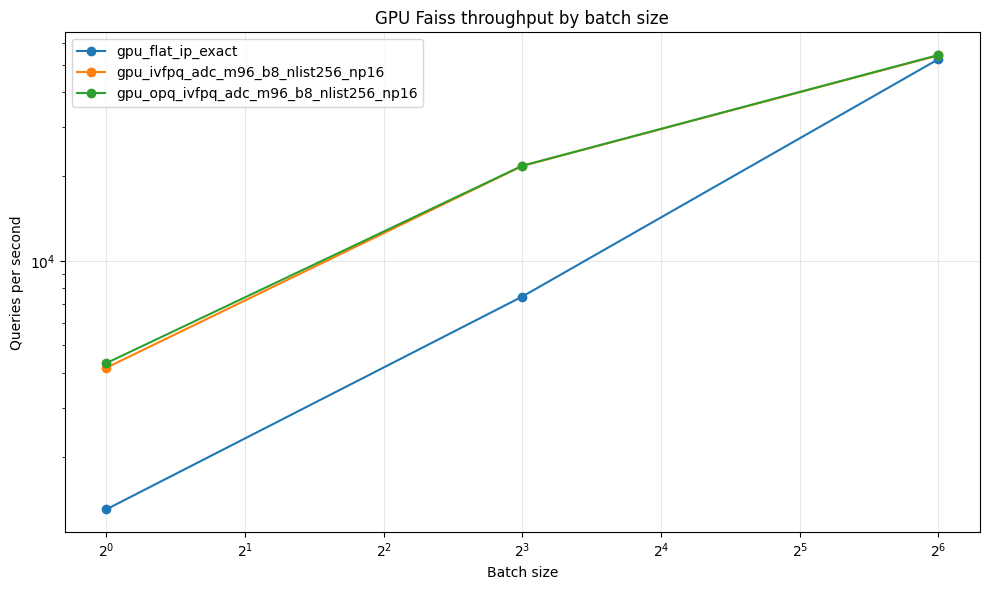

In [13]:
# Batch size effect on throughput

plt.figure(figsize=(10, 6))

for method, part in batch_benchmark_df.groupby("method"):
    plt.plot(
        part["batch_size"],
        part["queries_per_second"],
        marker="o",
        label=method,
    )

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Batch size")
plt.ylabel("Queries per second")
plt.title("GPU Faiss throughput by batch size")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [20]:
# 11. Stability benchmark: repeat each serving configuration

STABILITY_RUNS = 5

STABILITY_METHODS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
]

STABILITY_BATCH_SIZES = [1, 8, 64]


def percentile_summary(values):
    values = np.asarray(values, dtype=np.float64)

    return {
        "median": float(np.median(values)),
        "p10": float(np.percentile(values, 10)),
        "p90": float(np.percentile(values, 90)),
        "min": float(np.min(values)),
        "max": float(np.max(values)),
    }


stability_rows = []

for method in STABILITY_METHODS:
    if method not in faiss_indexes:
        print(f"Skip missing index: {method}")
        continue

    index = faiss_indexes[method]
    query_tensor = get_queries_for_faiss_method(method)

    nprobe = get_nprobe_from_method(method)
    if nprobe is not None:
        index.nprobe = nprobe

    for batch_size in STABILITY_BATCH_SIZES:
        run_p50 = []
        run_p95 = []
        run_qps = []
        run_total_seconds = []

        print(
            f"\nBenchmarking {method} | "
            f"batch={batch_size} | runs={STABILITY_RUNS}"
        )

        for run_id in range(STABILITY_RUNS):
            _, total_seconds, p50_ms, p95_ms = gpu_faiss_search_latency(
                index=index,
                queries_gpu=query_tensor,
                k=RANKING_K,
                batch_size=batch_size,
                warmup_batches=5,
            )

            qps = N_QUERIES / total_seconds

            run_p50.append(p50_ms)
            run_p95.append(p95_ms)
            run_qps.append(qps)
            run_total_seconds.append(total_seconds)

            print(
                f"  run {run_id + 1}/{STABILITY_RUNS}: "
                f"P50={p50_ms:.4f} ms | "
                f"P95={p95_ms:.4f} ms | "
                f"QPS={qps:.1f}"
            )

        p50_stats = percentile_summary(run_p50)
        p95_stats = percentile_summary(run_p95)
        qps_stats = percentile_summary(run_qps)
        total_stats = percentile_summary(run_total_seconds)

        stability_rows.append({
            "method": method,
            "batch_size": batch_size,
            "nprobe": nprobe,
            "runs": STABILITY_RUNS,

            "p50_latency_ms_median": p50_stats["median"],
            "p50_latency_ms_p10": p50_stats["p10"],
            "p50_latency_ms_p90": p50_stats["p90"],

            "p95_latency_ms_median": p95_stats["median"],
            "p95_latency_ms_p10": p95_stats["p10"],
            "p95_latency_ms_p90": p95_stats["p90"],

            "qps_median": qps_stats["median"],
            "qps_p10": qps_stats["p10"],
            "qps_p90": qps_stats["p90"],

            "total_seconds_median": total_stats["median"],
        })

stability_df = (
    pd.DataFrame(stability_rows)
    .sort_values(["batch_size", "method"])
    .reset_index(drop=True)
)

display(
    stability_df[
        [
            "method",
            "batch_size",
            "nprobe",
            "runs",
            "p50_latency_ms_median",
            "p95_latency_ms_median",
            "qps_median",
            "qps_p10",
            "qps_p90",
        ]
    ]
)


Benchmarking gpu_flat_ip_exact | batch=1 | runs=5
  run 1/5: P50=0.7339 ms | P95=0.8942 ms | QPS=1289.4
  run 2/5: P50=0.6661 ms | P95=0.6914 ms | QPS=1492.1
  run 3/5: P50=0.6685 ms | P95=0.7409 ms | QPS=1476.1
  run 4/5: P50=0.6692 ms | P95=0.7074 ms | QPS=1483.6
  run 5/5: P50=0.6682 ms | P95=0.7360 ms | QPS=1480.4

Benchmarking gpu_flat_ip_exact | batch=8 | runs=5
  run 1/5: P50=0.1331 ms | P95=0.1355 ms | QPS=7554.5
  run 2/5: P50=0.1340 ms | P95=0.1401 ms | QPS=7413.1
  run 3/5: P50=0.1331 ms | P95=0.1365 ms | QPS=7467.6
  run 4/5: P50=0.1334 ms | P95=0.1371 ms | QPS=7477.5
  run 5/5: P50=0.1343 ms | P95=0.1437 ms | QPS=7378.2

Benchmarking gpu_flat_ip_exact | batch=64 | runs=5
  run 1/5: P50=0.0190 ms | P95=0.0775 ms | QPS=48836.3
  run 2/5: P50=0.0193 ms | P95=0.0815 ms | QPS=46867.7
  run 3/5: P50=0.0230 ms | P95=0.0864 ms | QPS=41462.8
  run 4/5: P50=0.0229 ms | P95=0.0858 ms | QPS=40851.9
  run 5/5: P50=0.0242 ms | P95=0.0871 ms | QPS=38849.1

Benchmarking gpu_ivfpq_adc_m96

,method,batch_size,nprobe,runs,p50_latency_ms_median,p95_latency_ms_median,qps_median,qps_p10,qps_p90
0,gpu_flat_ip_exact,1,NaN,5,0.668527,0.735997,1480.393132,1364.093932,1488.727107
1,gpu_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,0.238341,0.315426,4022.116277,3937.686414,4121.879685
2,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,0.302632,0.361368,3168.375885,3056.128806,3298.699279
3,gpu_flat_ip_exact,8,NaN,5,0.133436,0.137133,7467.587731,7392.151193,7523.721954
4,gpu_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,0.047007,0.051865,21104.590147,20146.744206,21313.723515
5,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,0.053537,0.058194,18584.937682,16990.020078,18831.347852
6,gpu_flat_ip_exact,64,NaN,5,0.022891,0.085822,41462.786638,39650.194116,48048.879998
7,gpu_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,5,0.021185,0.046851,43978.910483,40716.636532,46240.999624
8,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,5,0.022032,0.041838,44154.833558,43108.479474,45395.956558


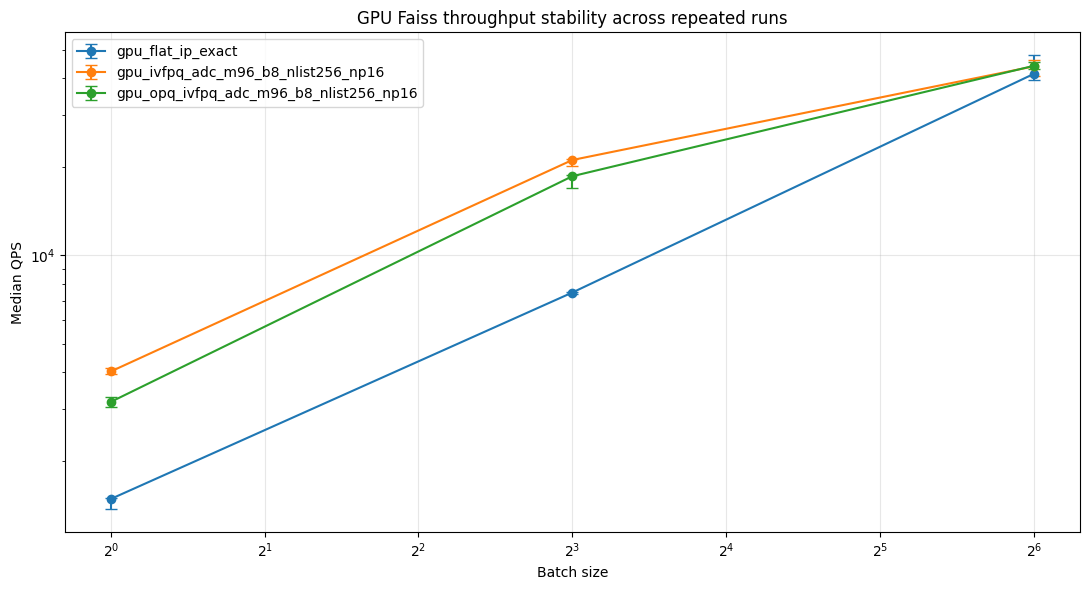

In [21]:
# Stability plot: median QPS with P10-P90 range

plt.figure(figsize=(11, 6))

for method, part in stability_df.groupby("method"):
    part = part.sort_values("batch_size")

    y = part["qps_median"]
    lower = y - part["qps_p10"]
    upper = part["qps_p90"] - y

    plt.errorbar(
        part["batch_size"],
        y,
        yerr=[lower, upper],
        marker="o",
        capsize=4,
        label=method,
    )

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Batch size")
plt.ylabel("Median QPS")
plt.title("GPU Faiss throughput stability across repeated runs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

Pareto frontier: deployment compression ratio vs FiQA nDCG@10


,method,retrieval_mode,deployment_compression_ratio,recall_at_5,recall_at_10,mrr_at_10,ndcg_at_10
0,scalar_int8,NaN,3.999999,0.369628,0.443932,0.444411,0.369097
1,opq_pq_m96_b8,NaN,13.586258,0.361657,0.440654,0.444936,0.367238
2,pq_m96_k256,NaN,14.938413,0.360059,0.437922,0.439251,0.365097
3,opq_pq_m64_b8,NaN,18.949999,0.353787,0.432826,0.432984,0.359528
4,pq_m64_k256,NaN,21.688125,0.341633,0.418368,0.428088,0.350792
5,opq_pq_m48_b8,NaN,23.610640,0.343974,0.417268,0.425869,0.350562
6,pq_m48_k256,NaN,28.017864,0.345778,0.417928,0.419804,0.346434
7,opq_pq_m24_b8,NaN,37.412848,0.307168,0.379675,0.382328,0.312054
8,pq_m24_k256,NaN,49.834265,0.284548,0.348881,0.350228,0.284876


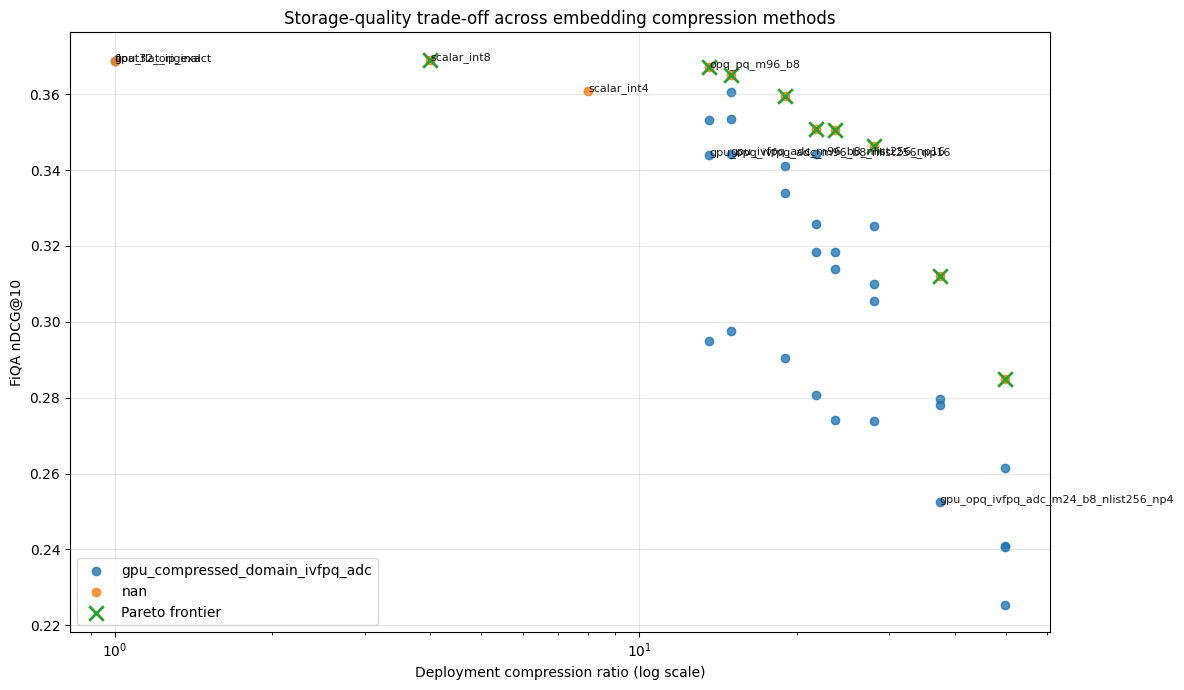

Pareto frontier: GPU Faiss QPS vs FiQA nDCG@10


,method,nprobe,queries_per_second,p50_latency_ms,p95_latency_ms,recall_at_10,ndcg_at_10
0,gpu_flat_ip_exact,NaN,34340.377263,0.027347,0.096319,0.441306,0.368671
1,gpu_ivfpq_adc_m96_b8_nlist256_np16,16.0,53118.672691,0.018489,0.033047,0.408453,0.344214
2,gpu_opq_ivfpq_adc_m64_b8_nlist256_np16,16.0,69289.658036,0.014099,0.026639,0.396031,0.333916
3,gpu_opq_ivfpq_adc_m48_b8_nlist256_np16,16.0,80923.880972,0.011894,0.024729,0.380602,0.313952
4,gpu_ivfpq_adc_m48_b8_nlist256_np16,16.0,82948.257567,0.011776,0.023640,0.370896,0.305514
5,gpu_ivfpq_adc_m96_b8_nlist256_np4,4.0,103782.736605,0.009082,0.029630,0.343489,0.297669
6,gpu_opq_ivfpq_adc_m64_b8_nlist256_np4,4.0,129440.761961,0.007586,0.020024,0.337178,0.290345
7,gpu_ivfpq_adc_m64_b8_nlist256_np4,4.0,130657.252359,0.007412,0.019340,0.335487,0.280679
8,gpu_opq_ivfpq_adc_m48_b8_nlist256_np4,4.0,146923.650053,0.006495,0.018853,0.328711,0.274094
9,gpu_ivfpq_adc_m48_b8_nlist256_np4,4.0,148189.176292,0.006302,0.018976,0.327559,0.273826


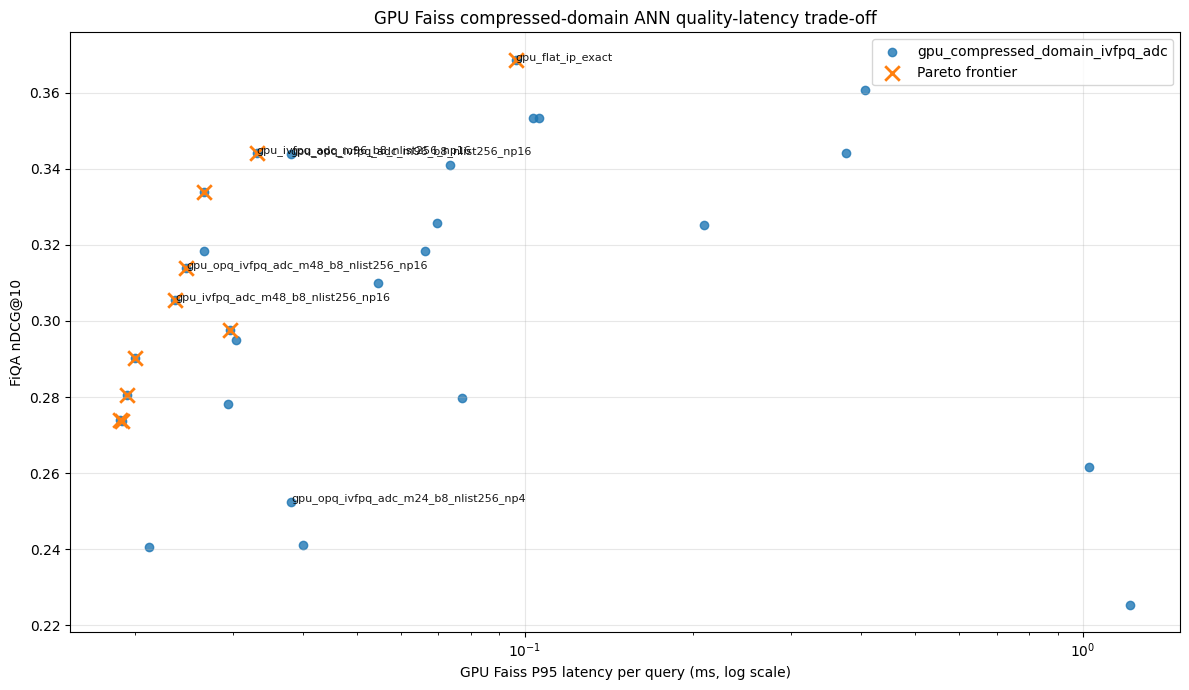

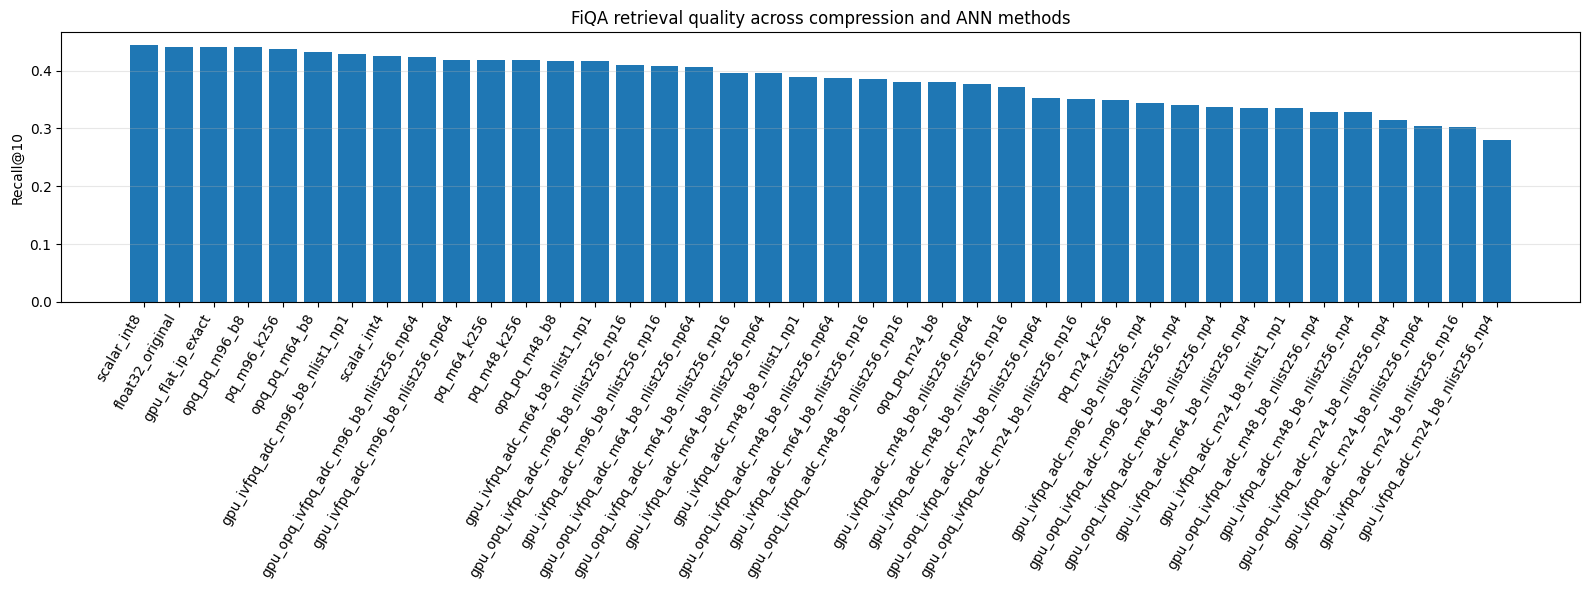

In [17]:
# Pareto frontier and charts

def pareto_frontier(df, x_col, y_col):
    """
    Keep rows not dominated on:
    - higher x is better
    - higher y is better
    """
    values = df[[x_col, y_col]].to_numpy()
    keep = np.ones(len(df), dtype=bool)

    for i, (x_i, y_i) in enumerate(values):
        dominated = (
            (values[:, 0] >= x_i)
            & (values[:, 1] >= y_i)
            & ((values[:, 0] > x_i) | (values[:, 1] > y_i))
        )

        if np.any(dominated):
            keep[i] = False

    return df.loc[keep].sort_values(x_col).reset_index(drop=True)


# ============================================================
# A. Storage-quality Pareto frontier
# All methods can be compared here because they share:
# deployment compression ratio + retrieval quality metrics.
# ============================================================

storage_quality_df = results_df.copy()

storage_frontier_df = pareto_frontier(
    storage_quality_df,
    "deployment_compression_ratio",
    "ndcg_at_10",
)

print("Pareto frontier: deployment compression ratio vs FiQA nDCG@10")

display(
    storage_frontier_df[
        [
            "method",
            "retrieval_mode",
            "deployment_compression_ratio",
            "recall_at_5",
            "recall_at_10",
            "mrr_at_10",
            "ndcg_at_10",
        ]
    ]
)

plt.figure(figsize=(12, 7))

for mode, part in storage_quality_df.groupby(
    "retrieval_mode",
    dropna=False,
):
    plt.scatter(
        part["deployment_compression_ratio"],
        part["ndcg_at_10"],
        label=str(mode),
        alpha=0.8,
    )

# Mark Pareto methods.
plt.scatter(
    storage_frontier_df["deployment_compression_ratio"],
    storage_frontier_df["ndcg_at_10"],
    marker="x",
    s=110,
    linewidths=2,
    label="Pareto frontier",
)

# Only annotate important methods to avoid unreadable labels.
ANNOTATE_STORAGE_METHODS = [
    "float32_original",
    "scalar_int8",
    "scalar_int4",
    "opq_pq_m96_b8",
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m24_b8_nlist256_np4",
]

for _, row in storage_quality_df.iterrows():
    if row["method"] in ANNOTATE_STORAGE_METHODS:
        plt.annotate(
            row["method"],
            (
                row["deployment_compression_ratio"],
                row["ndcg_at_10"],
            ),
            fontsize=8,
            alpha=0.9,
        )

plt.xscale("log")
plt.xlabel("Deployment compression ratio (log scale)")
plt.ylabel("FiQA nDCG@10")
plt.title("Storage-quality trade-off across embedding compression methods")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# B. GPU Faiss latency-quality trade-off
# Only Faiss GPU methods are allowed here.
# Do NOT mix reconstructed dense-search latency into this chart.
# ============================================================

adc_df = faiss_results_df.copy()

latency_frontier_df = pareto_frontier(
    adc_df,
    "queries_per_second",
    "ndcg_at_10",
)

print("Pareto frontier: GPU Faiss QPS vs FiQA nDCG@10")

display(
    latency_frontier_df[
        [
            "method",
            "nprobe",
            "queries_per_second",
            "p50_latency_ms",
            "p95_latency_ms",
            "recall_at_10",
            "ndcg_at_10",
        ]
    ]
)

plt.figure(figsize=(12, 7))

for mode, part in adc_df.groupby(
    "retrieval_mode",
    dropna=False,
):
    plt.scatter(
        part["p95_latency_ms"],
        part["ndcg_at_10"],
        label=str(mode),
        alpha=0.8,
    )

plt.scatter(
    latency_frontier_df["p95_latency_ms"],
    latency_frontier_df["ndcg_at_10"],
    marker="x",
    s=110,
    linewidths=2,
    label="Pareto frontier",
)

ANNOTATE_LATENCY_METHODS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_ivfpq_adc_m48_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m48_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m24_b8_nlist256_np4",
]

for _, row in adc_df.iterrows():
    if row["method"] in ANNOTATE_LATENCY_METHODS:
        plt.annotate(
            row["method"],
            (
                row["p95_latency_ms"],
                row["ndcg_at_10"],
            ),
            fontsize=8,
            alpha=0.9,
        )

plt.xscale("log")
plt.xlabel("GPU Faiss P95 latency per query (ms, log scale)")
plt.ylabel("FiQA nDCG@10")
plt.title("GPU Faiss compressed-domain ANN quality-latency trade-off")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# C. Recall@10 comparison chart
# Sort methods by Recall@10 instead of compression ratio.
# ============================================================

plot_df = (
    results_df
    .sort_values("recall_at_10", ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(16, 6))

plt.bar(
    plot_df["method"],
    plot_df["recall_at_10"],
)

plt.xticks(rotation=60, ha="right")
plt.ylabel("Recall@10")
plt.title("FiQA retrieval quality across compression and ANN methods")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
# 10. RAG-style retrieval inspection

def _print_retrieval_results(query_position, method, ranked_indices):
    """Print retrieved documents and qrels relevance labels."""
    qid = query_ids[query_position]

    print("Method:", method)
    print("Query ID:", qid)
    print("Query:", query_texts[query_position])
    print("Judged relevant document IDs:", list(qrels[qid].keys())[:10])
    print("\nRetrieved documents:")

    for rank, idx in enumerate(ranked_indices, start=1):
        doc_id = doc_ids[idx]
        title = corpus_rows[idx].get("title") or "(no title)"
        text = corpus_rows[idx].get("text") or ""
        relevance = qrels[qid].get(doc_id, 0)

        print(f"\n[{rank}] doc_id={doc_id}, qrels_score={relevance}")
        print("Title:", title[:180])
        print("Text :", text[:500].replace("\n", " "))


def _get_opq_rotation_key(faiss_method_name):
    """
    Example:
    gpu_opq_ivfpq_adc_m96_b8_nlist256_np16
    -> opq_pq_m96_b8
    """
    stem = faiss_method_name.split("_nlist")[0]
    return stem.replace(
        "gpu_opq_ivfpq_adc_",
        "opq_pq_"
    )


def show_retrieval(query_position, method="float32_original", top_k=5):
    """
    Inspect one query across:
    1. Dense / reconstruction-based methods in compressed_doc_embeddings
    2. GPU FAISS FlatIP / IVF-PQ ADC methods in faiss_indexes
    """

    if query_position < 0 or query_position >= N_QUERIES:
        raise IndexError(
            f"query_position must be between 0 and {N_QUERIES - 1}, "
            f"but got {query_position}."
        )

    # Original query is already on GPU in your notebook.
    q = X_queries[
        query_position:query_position + 1
    ].contiguous().float()

    # ------------------------------------------------------------
    # A. True FAISS GPU retrieval:
    #    - gpu_flat_ip_exact
    #    - gpu_ivfpq_adc_...
    #    - gpu_opq_ivfpq_adc_...
    # ------------------------------------------------------------
    if method in faiss_indexes:
        index = faiss_indexes[method]

        # OPQ IVF-PQ indexes were trained on rotated document embeddings.
        # Rotate query into the exact same learned OPQ space.
        if method.startswith("gpu_opq_ivfpq_adc_"):
            rotation_key = _get_opq_rotation_key(method)

            if rotation_key not in opq_rotations:
                available = sorted(opq_rotations.keys())
                raise KeyError(
                    f"Missing OPQ rotation '{rotation_key}'. "
                    f"Available rotations: {available}"
                )

            rotation = opq_rotations[rotation_key]
            q_for_search = (q @ rotation).contiguous()
        else:
            q_for_search = q

        # GPU Faiss index accepts CUDA torch tensors because
        # faiss.contrib.torch_utils was imported in the Faiss benchmark cell.
        _, ranked = index.search(q_for_search, top_k)

        ranked_np = to_numpy_ids(ranked)
        ranked_indices = [
            int(idx)
            for idx in ranked_np[0]
            if int(idx) >= 0
        ]

        _print_retrieval_results(
            query_position=query_position,
            method=method,
            ranked_indices=ranked_indices,
        )
        return ranked_indices

    # ------------------------------------------------------------
    # B. Earlier dense reconstruction-based baselines:
    #    float32_original / scalar_int8 / PQ / OPQ-PQ ...
    # ------------------------------------------------------------
    if method in compressed_doc_embeddings:
        docs = compressed_doc_embeddings[method]

        ranking, _ = gpu_topk(
            q,
            docs,
            top_k,
            batch_size=1,
        )

        ranked_indices = [
            int(idx)
            for idx in ranking[0].detach().cpu().tolist()
            if int(idx) >= 0
        ]

        _print_retrieval_results(
            query_position=query_position,
            method=method,
            ranked_indices=ranked_indices,
        )
        return ranked_indices

    known_methods = sorted(
        set(compressed_doc_embeddings.keys()) |
        set(faiss_indexes.keys())
    )

    raise ValueError(
        f"Unknown method: '{method}'.\n"
        f"Known methods:\n{known_methods}"
    )


# ----------------------------------------------------------------
# Example comparisons
# ----------------------------------------------------------------

# 1. Original float32 dense retrieval
show_retrieval(
    query_position=0,
    method="float32_original",
    top_k=5,
)

# 2. Genuine GPU OPQ + IVF-PQ compressed-domain ADC
# Recommended balanced configuration:
show_retrieval(
    query_position=0,
    method="gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    top_k=5,
)

# 3. Highest-quality ANN variant:
show_retrieval(
    query_position=0,
    method="gpu_opq_ivfpq_adc_m96_b8_nlist256_np64",
    top_k=5,
)

# 4. Pure PQ ADC without OPQ:
show_retrieval(
    query_position=0,
    method="gpu_ivfpq_adc_m96_b8_nlist256_np16",
    top_k=5,
)


Method: float32_original
Query ID: 4641
Query: Where should I park my rainy-day / emergency fund?
Judged relevant document IDs: ['44594', '406219', '319954', '397358', '88327']

Retrieved documents:

[1] doc_id=44594, qrels_score=1
Title: (no title)
Text : "First off, you generally want to park your emergency fund somewhere that is ""safe"", meaning something that is not subject to market fluctuations.  Your emergency fund is something you need to be able to count on when times are tough!  That rules out things like stock market investments. Secondly, you need to think about how quickly you will need access to the money.  If you have an emergency, odds are you don't want to be waiting around for weeks/months/years for the money to become available

[2] doc_id=254572, qrels_score=0
Title: (no title)
Text : From a budgeting perspective, the emergency fund is a category in which you've budgeted funds for the unexpected.  These are things that weren't able to be predicted and budgeted for 

[24607, 4309, 39076, 42126, 23574]

In [23]:
# 11. Export results and reproducibility metadata

results_df.to_csv(
    RESULT_DIR / "fiqa_rag_compression_results.csv",
    index=False,
    encoding="utf-8-sig",
)
frontier_df.to_csv(
    RESULT_DIR / "fiqa_rag_pareto_frontier.csv",
    index=False,
    encoding="utf-8-sig",
)

metadata = {
    "dataset": "FiQA-2018 (BEIR)",
    "corpus_documents": int(N_DOCS),
    "test_queries": int(N_QUERIES),
    "embedding_model": EMBEDDING_MODEL,
    "embedding_dimension": int(D),
    "device": str(DEVICE),
    "gpu": torch.cuda.get_device_name(0),
    "retrieval_metrics": ["Recall@5", "Recall@10", "MRR@10", "nDCG@10"],
    "storage_rule": (
        "Document embeddings only; deployment bytes include codes, codebooks/scales, "
        "and required learned transforms."
    ),
    "retrieval_modes": [
        "dense cosine retrieval over reconstructed vectors (scalar/custom PQ/OPQ baseline)",
        "FAISS GPU compressed-domain IVF-PQ ADC (GPU training, index build, and search)",
    ],
    "faiss": {
        "backend": "faiss-gpu-cu12 / CUDA",
        "gpu_training": True,
        "nlist": FAISS_NLIST,
        "nprobe_values": FAISS_NPROBE_VALUES,
        "pq_settings": FAISS_PQ_SETTINGS,
        "opq_settings": FAISS_OPQ_SETTINGS,
    },
    "pq_settings": PQ_SETTINGS,
    "opq_settings": OPQ_SETTINGS,
}
with open(RESULT_DIR / "fiqa_rag_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, ensure_ascii=False, indent=2)

with open(RESULT_DIR / "research_notes.md", "w", encoding="utf-8") as f:
    f.write("# FiQA RAG Compression Benchmark Notes\n\n")
    f.write("- FiQA is evaluated as query-to-document retrieval with BEIR qrels.\n")
    f.write("- Document embeddings are compressed; query embeddings remain float32.\n")
    f.write("- Deployment storage counts document payload, PQ codebooks, and OPQ transforms.\n")
    f.write("- Baseline scalar/custom PQ results use reconstructed-document dense retrieval.\n")
    f.write("- FAISS GPU IVF-PQ rows train, build, and search on CUDA; document vectors stay compressed during ADC search.\n")
    f.write("- GPU latency uses synchronized batch measurements; do not compare it directly to CPU timings.\n")
    f.write("- Compare P50/P95 latency, QPS, serialized index bytes, and recall/nDCG together.\n")
    f.write("- Interpret Pareto points using deployment compression ratio and nDCG@10 together.\n")

print("Saved results in:", RESULT_DIR.resolve())

NameError: name 'frontier_df' is not defined

## What this completes

After this notebook runs, your project has three evaluation layers:

1. **AG News** — controlled embedding-neighbor and deployment-overhead benchmark.
2. **FiQA reconstructed-vector benchmark** — query-to-document quality under scalar, custom GPU PQ, and custom GPU OPQ-PQ compression.
3. **FAISS GPU compressed-domain benchmark** — GPU `IVF-PQ` ADC with GPU-side training, index construction, and batched search; plus a PyTorch-GPU-learned OPQ transform.

The remaining product step is a small retrieval API that loads the selected serialized CPU FAISS index, transfers it to GPU at service startup, exposes `/search`, and reports index type, compressed size, latency, and ranked source documents.


In [24]:
# 12. Export README-ready benchmark artifacts

from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

ARTIFACT_DIR = Path("fiqa_rag_results/readme_artifacts")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# A. Main representative results table
# ------------------------------------------------------------

README_METHODS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_ivfpq_adc_m24_b8_nlist256_np4",
]

main_results_df = (
    faiss_results_df[
        faiss_results_df["method"].isin(README_METHODS)
    ]
    .copy()
)

main_results_df["deployment_compression_ratio"] = (
    main_results_df["deployment_compression_ratio"].round(2)
)

main_results_df["recall_at_10"] = (
    main_results_df["recall_at_10"].round(4)
)

main_results_df["ndcg_at_10"] = (
    main_results_df["ndcg_at_10"].round(4)
)

main_results_df["p50_latency_ms"] = (
    main_results_df["p50_latency_ms"].round(4)
)

main_results_df["p95_latency_ms"] = (
    main_results_df["p95_latency_ms"].round(4)
)

main_results_df["queries_per_second"] = (
    main_results_df["queries_per_second"].round(1)
)

main_results_df = main_results_df[
    [
        "method",
        "nprobe",
        "deployment_compression_ratio",
        "recall_at_10",
        "ndcg_at_10",
        "p50_latency_ms",
        "p95_latency_ms",
        "queries_per_second",
    ]
].sort_values(
    "recall_at_10",
    ascending=False,
).reset_index(drop=True)

main_results_df.to_csv(
    ARTIFACT_DIR / "main_gpu_adc_results.csv",
    index=False,
)

print("README main result table:")
display(main_results_df)

README main result table:


,method,nprobe,deployment_compression_ratio,recall_at_10,ndcg_at_10,p50_latency_ms,p95_latency_ms,queries_per_second
0,gpu_flat_ip_exact,NaN,1.00,0.4413,0.3687,0.0273,0.0963,34340.4
1,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,16.0,13.59,0.4099,0.3440,0.0194,0.0380,50692.0
2,gpu_ivfpq_adc_m96_b8_nlist256_np16,16.0,14.94,0.4085,0.3442,0.0185,0.0330,53118.7
3,gpu_ivfpq_adc_m24_b8_nlist256_np4,4.0,49.83,0.2806,0.2254,0.0049,1.2114,28838.4


In [25]:
# 13. Export repeated-run stability results

STABILITY_README_METHODS = [
    "gpu_flat_ip_exact",
    "gpu_ivfpq_adc_m96_b8_nlist256_np16",
    "gpu_opq_ivfpq_adc_m96_b8_nlist256_np16",
]

stability_readme_df = (
    stability_df[
        stability_df["method"].isin(STABILITY_README_METHODS)
    ]
    .copy()
)

stability_readme_df = stability_readme_df[
    [
        "method",
        "batch_size",
        "nprobe",
        "runs",
        "p50_latency_ms_median",
        "p95_latency_ms_median",
        "qps_median",
        "qps_p10",
        "qps_p90",
    ]
].sort_values(
    ["batch_size", "method"]
).reset_index(drop=True)

for col in [
    "p50_latency_ms_median",
    "p95_latency_ms_median",
    "qps_median",
    "qps_p10",
    "qps_p90",
]:
    stability_readme_df[col] = stability_readme_df[col].round(3)

stability_readme_df.to_csv(
    ARTIFACT_DIR / "stability_batch_benchmark.csv",
    index=False,
)

print("Repeated-run stability benchmark:")
display(stability_readme_df)

Repeated-run stability benchmark:


,method,batch_size,nprobe,runs,p50_latency_ms_median,p95_latency_ms_median,qps_median,qps_p10,qps_p90
0,gpu_flat_ip_exact,1,NaN,5,0.669,0.736,1480.393,1364.094,1488.727
1,gpu_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,0.238,0.315,4022.116,3937.686,4121.880
2,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,1,16.0,5,0.303,0.361,3168.376,3056.129,3298.699
3,gpu_flat_ip_exact,8,NaN,5,0.133,0.137,7467.588,7392.151,7523.722
4,gpu_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,0.047,0.052,21104.590,20146.744,21313.724
5,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,8,16.0,5,0.054,0.058,18584.938,16990.020,18831.348
6,gpu_flat_ip_exact,64,NaN,5,0.023,0.086,41462.787,39650.194,48048.880
7,gpu_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,5,0.021,0.047,43978.910,40716.637,46241.000
8,gpu_opq_ivfpq_adc_m96_b8_nlist256_np16,64,16.0,5,0.022,0.042,44154.834,43108.479,45395.957


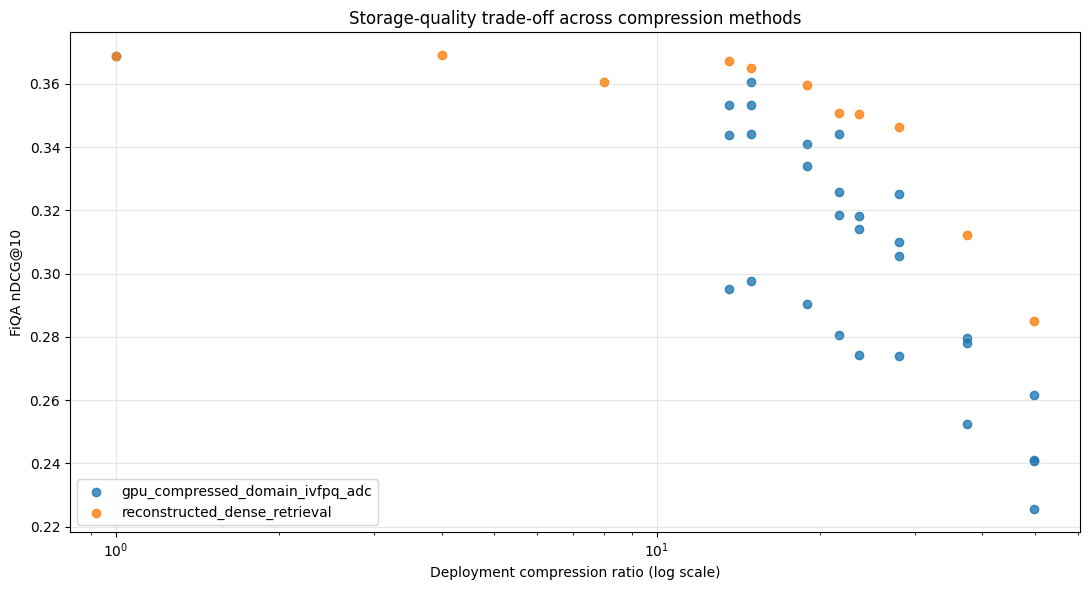

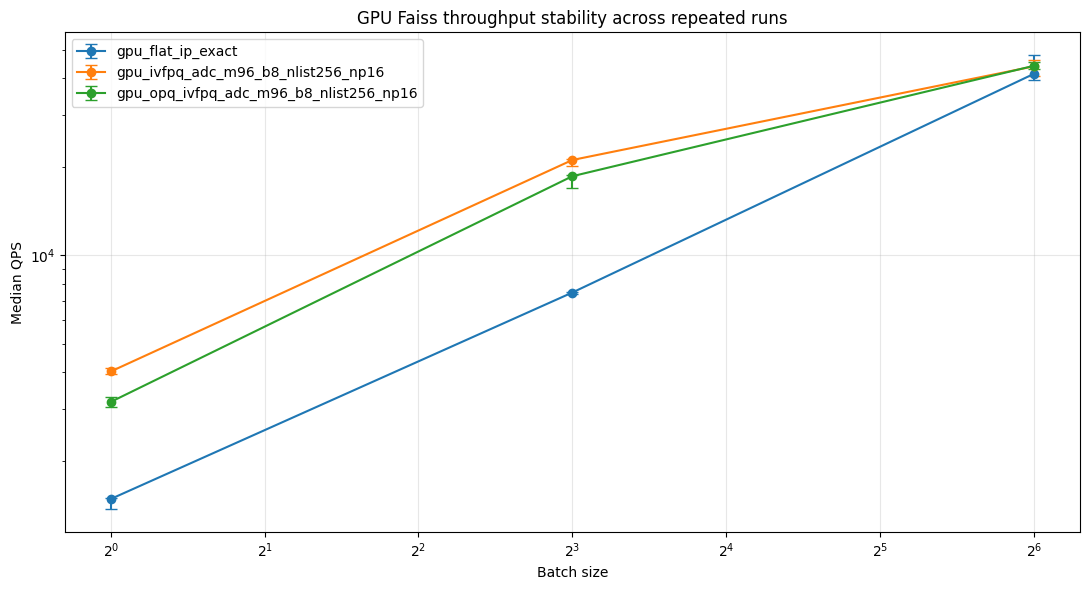

Saved:
fiqa_rag_results/readme_artifacts/storage_quality_tradeoff.png
fiqa_rag_results/readme_artifacts/throughput_stability.png


In [26]:
# 14. Save README figures

# Figure 1: storage-quality trade-off
plot_results_df = results_df.copy()

plot_results_df["retrieval_mode"] = (
    plot_results_df["retrieval_mode"]
    .fillna("reconstructed_dense_retrieval")
)

plt.figure(figsize=(11, 6))

for mode, part in plot_results_df.groupby("retrieval_mode"):
    plt.scatter(
        part["deployment_compression_ratio"],
        part["ndcg_at_10"],
        label=str(mode),
        alpha=0.8,
    )

plt.xscale("log")
plt.xlabel("Deployment compression ratio (log scale)")
plt.ylabel("FiQA nDCG@10")
plt.title("Storage-quality trade-off across compression methods")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

storage_fig_path = ARTIFACT_DIR / "storage_quality_tradeoff.png"
plt.savefig(storage_fig_path, dpi=180, bbox_inches="tight")
plt.show()


# Figure 2: repeated-run throughput stability
plt.figure(figsize=(11, 6))

for method, part in stability_df.groupby("method"):
    part = part.sort_values("batch_size")

    median_qps = part["qps_median"]
    lower = median_qps - part["qps_p10"]
    upper = part["qps_p90"] - median_qps

    plt.errorbar(
        part["batch_size"],
        median_qps,
        yerr=[lower, upper],
        marker="o",
        capsize=4,
        label=method,
    )

plt.xscale("log", base=2)
plt.yscale("log")
plt.xlabel("Batch size")
plt.ylabel("Median QPS")
plt.title("GPU Faiss throughput stability across repeated runs")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

throughput_fig_path = ARTIFACT_DIR / "throughput_stability.png"
plt.savefig(throughput_fig_path, dpi=180, bbox_inches="tight")
plt.show()

print("Saved:")
print(storage_fig_path)
print(throughput_fig_path)

In [27]:
# 15. Generate README markdown table

readme_table = main_results_df.rename(
    columns={
        "method": "Method",
        "nprobe": "nprobe",
        "deployment_compression_ratio": "Compression",
        "recall_at_10": "Recall@10",
        "ndcg_at_10": "nDCG@10",
        "p50_latency_ms": "P50 ms/query",
        "p95_latency_ms": "P95 ms/query",
        "queries_per_second": "QPS",
    }
)

markdown_table = readme_table.to_markdown(index=False)

print("Copy this into README:\n")
print(markdown_table)

with open(
    ARTIFACT_DIR / "main_results_table.md",
    "w",
    encoding="utf-8",
) as f:
    f.write(markdown_table)

print("\nSaved:", ARTIFACT_DIR / "main_results_table.md")

Copy this into README:

| Method                                 |   nprobe |   Compression |   Recall@10 |   nDCG@10 |   P50 ms/query |   P95 ms/query |     QPS |
|:---------------------------------------|---------:|--------------:|------------:|----------:|---------------:|---------------:|--------:|
| gpu_flat_ip_exact                      |      nan |          1    |      0.4413 |    0.3687 |         0.0273 |         0.0963 | 34340.4 |
| gpu_opq_ivfpq_adc_m96_b8_nlist256_np16 |       16 |         13.59 |      0.4099 |    0.344  |         0.0194 |         0.038  | 50692   |
| gpu_ivfpq_adc_m96_b8_nlist256_np16     |       16 |         14.94 |      0.4085 |    0.3442 |         0.0185 |         0.033  | 53118.7 |
| gpu_ivfpq_adc_m24_b8_nlist256_np4      |        4 |         49.83 |      0.2806 |    0.2254 |         0.0049 |         1.2114 | 28838.4 |

Saved: fiqa_rag_results/readme_artifacts/main_results_table.md


In [28]:
from pathlib import Path
import json
import faiss

# Export the representative plain IVF-PQ service index:
# M=96, 8 bits/subquantizer, nlist=256, nprobe=16
SERVICE_METHOD = "gpu_ivfpq_adc_m96_b8_nlist256_np16"
SERVICE_NPROBE = 16
SERVICE_DIR = Path("service_artifacts/fiqa_ivfpq_m96")
SERVICE_DIR.mkdir(parents=True, exist_ok=True)

if SERVICE_METHOD not in faiss_indexes:
    raise KeyError(
        f"Missing {SERVICE_METHOD}. "
        f"Available examples: {list(faiss_indexes)[:5]}"
    )

# This is a GPU Faiss index in the benchmark.
gpu_service_index = faiss_indexes[SERVICE_METHOD]
gpu_service_index.nprobe = SERVICE_NPROBE

# Convert to a CPU-serializable Faiss index for the first API version.
cpu_service_index = faiss.index_gpu_to_cpu(gpu_service_index)
cpu_service_index.nprobe = SERVICE_NPROBE

# Save index
faiss.write_index(cpu_service_index, str(SERVICE_DIR / "index.faiss"))

# Save metadata in exactly the same order as vectors were added.
with (SERVICE_DIR / "documents.jsonl").open("w", encoding="utf-8") as f:
    for doc_id, row in zip(doc_ids, corpus_rows):
        f.write(json.dumps({
            "doc_id": str(doc_id),
            "title": str(row.get("title") or ""),
            "text": str(row.get("text") or ""),
        }, ensure_ascii=False) + "\n")

service_config = {
    "embedding_model": EMBEDDING_MODEL,
    "index_type": type(cpu_service_index).__name__,
    "vector_count": int(cpu_service_index.ntotal),
    "dimension": int(cpu_service_index.d),
    "default_nprobe": SERVICE_NPROBE,
    "normalization": "L2-normalized embeddings; inner-product search",
    "source_method": SERVICE_METHOD,
}
(SERVICE_DIR / "service_config.json").write_text(
    json.dumps(service_config, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

print("Export complete:", SERVICE_DIR)
print("Index vectors:", cpu_service_index.ntotal)
print("Metadata rows:", len(doc_ids))
print("Files:", [p.name for p in SERVICE_DIR.iterdir()])

Export complete: service_artifacts/fiqa_ivfpq_m96
Index vectors: 57638
Metadata rows: 57638
Files: ['service_config.json', 'index.faiss', 'documents.jsonl']


In [29]:
!zip -r fiqa_ivfpq_m96_service_artifacts.zip service_artifacts/fiqa_ivfpq_m96

from google.colab import files
files.download("fiqa_ivfpq_m96_service_artifacts.zip")

  adding: service_artifacts/fiqa_ivfpq_m96/ (stored 0%)
  adding: service_artifacts/fiqa_ivfpq_m96/service_config.json (deflated 27%)
  adding: service_artifacts/fiqa_ivfpq_m96/index.faiss (deflated 5%)
  adding: service_artifacts/fiqa_ivfpq_m96/documents.jsonl (deflated 63%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [30]:
import json
from google.colab import files

SERVICE_DIR = Path("service_artifacts/fiqa_ivfpq_m96")

doc_ids_path = SERVICE_DIR / "doc_ids.json"
doc_ids_path.write_text(
    json.dumps([str(doc_id) for doc_id in doc_ids], ensure_ascii=False),
    encoding="utf-8",
)

print("Saved:", doc_ids_path)
print("Document IDs:", len(doc_ids))

files.download(str(doc_ids_path))

Saved: service_artifacts/fiqa_ivfpq_m96/doc_ids.json
Document IDs: 57638


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>